<a href="https://colab.research.google.com/github/Niveditha-28/Memetic-Algorithm/blob/main/MemeticAlgorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Memetic Algorithm

Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

BenchMark Functions

In [3]:
def sphere(x):
    x = np.asarray(x)
    return np.sum(x ** 2, axis=-1)

In [4]:
def rastrigin(x):
    x = np.asarray(x)
    return (
        10 * x.shape[-1]
        + np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x), axis=-1)
    )

Settings

In [5]:
FUNCTION_NAME = "rastrigin"   # "sphere" or "rastrigin"

OBJECTIVE = {
    "sphere": sphere,
    "rastrigin": rastrigin
}[FUNCTION_NAME]

DIMENSIONS = 2
POP_SIZE = 50
GENERATIONS = 100

LOWER_BOUND = -5.12
UPPER_BOUND = 5.12

CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.2
MUTATION_SCALE = 0.05

TOURNAMENT_SIZE = 3

LOCAL_SEARCH_RATE = 0.3
LOCAL_SEARCH_STEPS = 20
LOCAL_SEARCH_INITIAL_STEP = 0.05

NUMBER_OF_RUNS = 20
BASE_SEED = 42
SUCCESS_TOLERANCE = 1e-6

# Both benchmark functions have their global minimum at zero.
KNOWN_OPTIMUM = 0.0

Initialize Population

In [6]:
def initialize_population(rng):
    return rng.uniform(
        LOWER_BOUND,
        UPPER_BOUND,
        size=(POP_SIZE, DIMENSIONS)
    )

Tournament selection

In [7]:
def tournament_selection(population, fitness, rng):
    indices = rng.choice(
        len(population),
        size=TOURNAMENT_SIZE,
        replace=False
    )

    winner = indices[np.argmin(fitness[indices])]

    return population[winner].copy()

Crossover

In [8]:
def crossover(parent1, parent2, rng):
    if rng.random() < CROSSOVER_RATE:
        alpha = rng.random(DIMENSIONS)

        child1 = alpha * parent1 + (1 - alpha) * parent2
        child2 = alpha * parent2 + (1 - alpha) * parent1

        return child1, child2

    return parent1.copy(), parent2.copy()

Mutation

In [9]:
def mutation(child, rng):
    mask = rng.random(DIMENSIONS) < MUTATION_RATE

    noise = rng.normal(
        loc=0.0,
        scale=MUTATION_SCALE * (UPPER_BOUND - LOWER_BOUND),
        size=DIMENSIONS
    )

    mutated_child = child + mask * noise

    return np.clip(
        mutated_child,
        LOWER_BOUND,
        UPPER_BOUND
    )

Local search

In [10]:
def local_search(solution, evaluate, rng):
    best = solution.copy()
    best_value = evaluate(best)

    step = (
        LOCAL_SEARCH_INITIAL_STEP
        * (UPPER_BOUND - LOWER_BOUND)
    )

    for _ in range(LOCAL_SEARCH_STEPS):
        improved = False

        for coordinate in rng.permutation(DIMENSIONS):
            for direction in (-1, 1):
                candidate = best.copy()
                candidate[coordinate] += direction * step

                candidate = np.clip(
                    candidate,
                    LOWER_BOUND,
                    UPPER_BOUND
                )

                candidate_value = evaluate(candidate)

                if candidate_value < best_value:
                    best = candidate
                    best_value = candidate_value
                    improved = True

        if not improved:
            step *= 0.5

        if step < 1e-6:
            break

    return best

Complete memetic algorithm

In [11]:
def memetic_algorithm(seed):
    rng = np.random.default_rng(seed)

    evaluation_count = 0

    # Counts every candidate evaluated, including local search.
    def evaluate(x):
        nonlocal evaluation_count

        x = np.asarray(x)

        if x.ndim == 1:
            evaluation_count += 1
            return float(OBJECTIVE(x))

        evaluation_count += x.shape[0]
        return OBJECTIVE(x)

    start_time = perf_counter()

    population = initialize_population(rng)
    initial_population = population.copy()

    fitness = evaluate(population)

    best_index = np.argmin(fitness)
    best_solution = population[best_index].copy()
    best_fitness = float(fitness[best_index])

    convergence = [best_fitness]
    trajectory = [best_solution.copy()]

    for generation in range(GENERATIONS):
        # Elitism preserves the best solution.
        new_population = [best_solution.copy()]

        while len(new_population) < POP_SIZE:
            parent1 = tournament_selection(
                population, fitness, rng
            )

            parent2 = tournament_selection(
                population, fitness, rng
            )

            child1, child2 = crossover(
                parent1, parent2, rng
            )

            for child in (child1, child2):
                child = mutation(child, rng)

                if rng.random() < LOCAL_SEARCH_RATE:
                    child = local_search(
                        child, evaluate, rng
                    )

                new_population.append(child)

                if len(new_population) == POP_SIZE:
                    break

        population = np.array(new_population)
        fitness = evaluate(population)

        best_index = np.argmin(fitness)

        if fitness[best_index] < best_fitness:
            best_fitness = float(fitness[best_index])
            best_solution = population[best_index].copy()

        convergence.append(best_fitness)
        trajectory.append(best_solution.copy())

    elapsed_time = perf_counter() - start_time

    return {
        "seed": seed,
        "best_solution": best_solution,
        "best_fitness": best_fitness,
        "convergence": np.array(convergence),
        "trajectory": np.array(trajectory),
        "initial_population": initial_population,
        "final_population": population.copy(),
        "evaluations": evaluation_count,
        "runtime_seconds": elapsed_time
    }

Solution


In [12]:
result = memetic_algorithm(BASE_SEED)

print("Function:", FUNCTION_NAME)
print("Best position:", result["best_solution"])
print("Best fitness:", f'{result["best_fitness"]:.10e}')
print("Known optimal position:", np.zeros(DIMENSIONS))
print("Known optimal fitness:", KNOWN_OPTIMUM)
print("Objective evaluations:", result["evaluations"])
print("Runtime:", f'{result["runtime_seconds"]:.3f} seconds')

Function: rastrigin
Best position: [-6.76492658e-10  2.54561256e-09]
Best fitness: 0.0000000000e+00
Known optimal position: [0. 0.]
Known optimal fitness: 0.0
Objective evaluations: 120640
Runtime: 4.041 seconds


Search space visualization function

In [13]:
def visualize_search_space():
    if DIMENSIONS != 2:
        raise ValueError(
            "Search space visualization requires DIMENSIONS = 2."
        )

    coordinates = np.linspace(
        LOWER_BOUND, UPPER_BOUND, 250
    )

    X, Y = np.meshgrid(coordinates, coordinates)

    points = np.stack((X, Y), axis=-1)
    Z = OBJECTIVE(points)

    fig = plt.figure(figsize=(14, 5))

    # 3D surface
    ax1 = fig.add_subplot(121, projection="3d")

    surface = ax1.plot_surface(
        X, Y, Z,
        cmap="viridis",
        linewidth=0,
        alpha=0.9
    )

    ax1.scatter(
        0, 0, KNOWN_OPTIMUM,
        color="red",
        s=60,
        label="Global optimum"
    )

    ax1.set_xlabel("x₁")
    ax1.set_ylabel("x₂")
    ax1.set_zlabel("Objective value")
    ax1.set_title(f"{FUNCTION_NAME.capitalize()} — Surface")
    ax1.legend()

    fig.colorbar(surface, ax=ax1, shrink=0.6, pad=0.1)

    # 2D contours
    ax2 = fig.add_subplot(122)

    contour = ax2.contourf(
        X, Y, Z,
        levels=40,
        cmap="viridis"
    )

    ax2.scatter(
        0, 0,
        color="red",
        marker="*",
        s=180,
        edgecolors="black",
        label="Global optimum"
    )

    ax2.set_xlabel("x₁")
    ax2.set_ylabel("x₂")
    ax2.set_title(f"{FUNCTION_NAME.capitalize()} — Contours")
    ax2.set_aspect("equal")
    ax2.legend()

    fig.colorbar(contour, ax=ax2, label="Objective value")

    plt.tight_layout()
    plt.show()

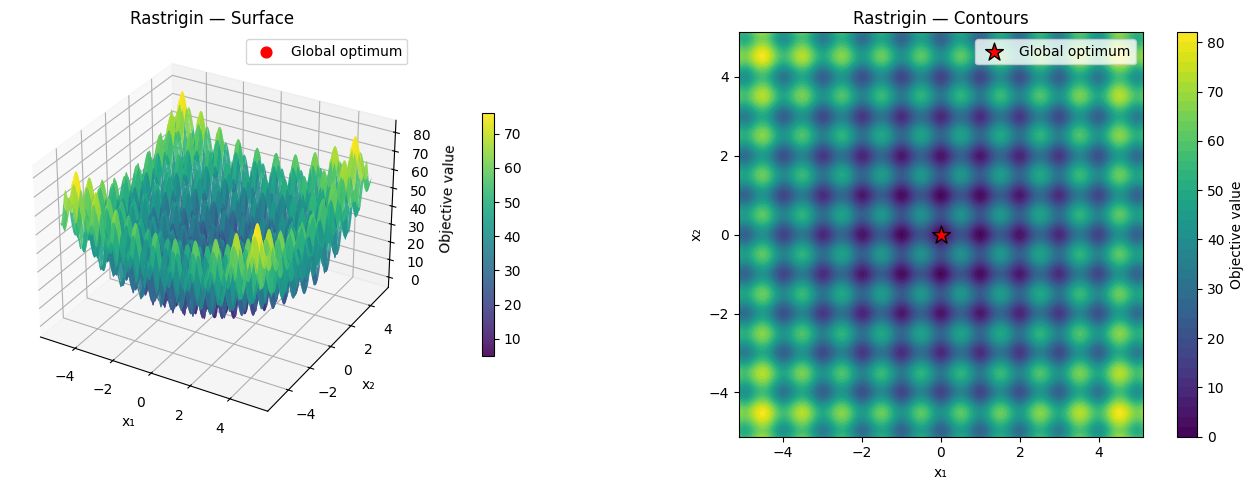

In [14]:
visualize_search_space()

Convergence plotting function

In [15]:
def plot_convergence(result):
    generations = np.arange(
        len(result["convergence"])
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        generations,
        result["convergence"],
        color="purple",
        linewidth=2
    )

    plt.xlabel("Generation")
    plt.ylabel("Best objective value")
    plt.title(
        f"Memetic Algorithm Convergence — "
        f"{FUNCTION_NAME.capitalize()}"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

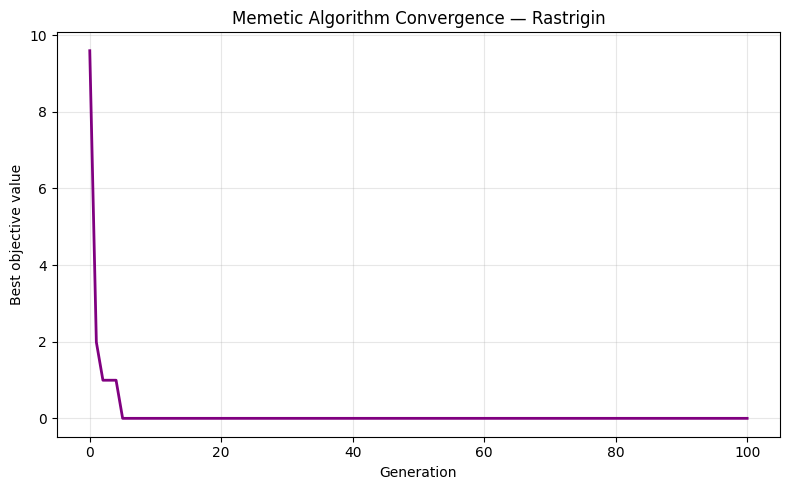

In [16]:
plot_convergence(result)

Trajectory plotting function

In [17]:
def plot_trajectory(result):
    if DIMENSIONS != 2:
        raise ValueError(
            "Trajectory visualization requires DIMENSIONS = 2."
        )

    coordinates = np.linspace(
        LOWER_BOUND, UPPER_BOUND, 250
    )

    X, Y = np.meshgrid(coordinates, coordinates)
    Z = OBJECTIVE(np.stack((X, Y), axis=-1))

    trajectory = result["trajectory"]

    fig, ax = plt.subplots(figsize=(9, 7))

    contour = ax.contourf(
        X, Y, Z,
        levels=40,
        cmap="viridis"
    )

    fig.colorbar(
        contour, ax=ax, label="Objective value"
    )

    ax.scatter(
        result["initial_population"][:, 0],
        result["initial_population"][:, 1],
        color="white",
        s=18,
        alpha=0.35,
        label="Initial population"
    )

    ax.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        "w.-",
        linewidth=1.5,
        markersize=5,
        label="Best solution trajectory"
    )

    ax.scatter(
        trajectory[0, 0],
        trajectory[0, 1],
        color="orange",
        s=100,
        edgecolors="black",
        label="Starting best position",
        zorder=5
    )

    ax.scatter(
        trajectory[-1, 0],
        trajectory[-1, 1],
        color="red",
        marker="X",
        s=130,
        label="Final best position",
        zorder=6
    )

    ax.scatter(
        0, 0,
        color="cyan",
        marker="*",
        s=180,
        edgecolors="black",
        label="Global optimum",
        zorder=7
    )

    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(
        f"Memetic Algorithm Trajectory — "
        f"{FUNCTION_NAME.capitalize()}"
    )

    ax.set_aspect("equal")
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

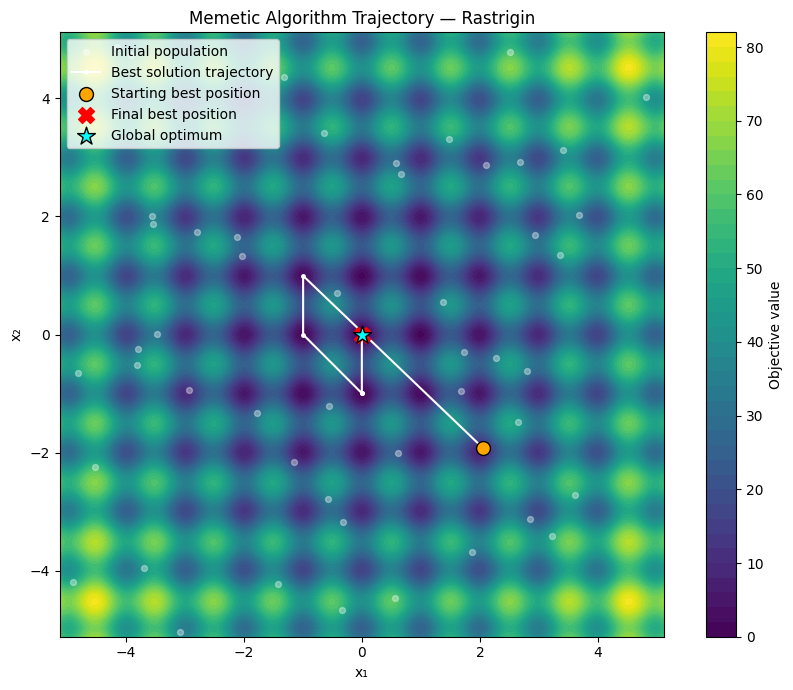

In [18]:
plot_trajectory(result)

In [19]:
def run_experiments(number_of_runs, base_seed):
    results = []

    for run in range(number_of_runs):
        seed = base_seed + run
        run_result = memetic_algorithm(seed)
        results.append(run_result)

        print(
            f"Run {run + 1:2d}/{number_of_runs} | "
            f"Fitness: {run_result['best_fitness']:.6e} | "
            f"Time: {run_result['runtime_seconds']:.2f}s"
        )

    return results

In [20]:
if NUMBER_OF_RUNS < 2:
    raise ValueError(
        "Use at least two runs for sample standard deviation."
    )

all_results = [result]

all_results.extend(
    run_experiments(
        number_of_runs=NUMBER_OF_RUNS - 1,
        base_seed=BASE_SEED + 1
    )
)

Run  1/19 | Fitness: 0.000000e+00 | Time: 4.11s
Run  2/19 | Fitness: 0.000000e+00 | Time: 2.84s
Run  3/19 | Fitness: 0.000000e+00 | Time: 2.77s
Run  4/19 | Fitness: 0.000000e+00 | Time: 2.83s
Run  5/19 | Fitness: 0.000000e+00 | Time: 3.47s
Run  6/19 | Fitness: 0.000000e+00 | Time: 3.17s
Run  7/19 | Fitness: 0.000000e+00 | Time: 2.72s
Run  8/19 | Fitness: 0.000000e+00 | Time: 2.71s
Run  9/19 | Fitness: 0.000000e+00 | Time: 2.69s
Run 10/19 | Fitness: 0.000000e+00 | Time: 4.15s
Run 11/19 | Fitness: 0.000000e+00 | Time: 2.81s
Run 12/19 | Fitness: 0.000000e+00 | Time: 2.82s
Run 13/19 | Fitness: 0.000000e+00 | Time: 2.85s
Run 14/19 | Fitness: 0.000000e+00 | Time: 4.14s
Run 15/19 | Fitness: 0.000000e+00 | Time: 2.80s
Run 16/19 | Fitness: 0.000000e+00 | Time: 2.84s
Run 17/19 | Fitness: 0.000000e+00 | Time: 2.70s
Run 18/19 | Fitness: 0.000000e+00 | Time: 3.40s
Run 19/19 | Fitness: 0.000000e+00 | Time: 3.58s


In [21]:
def statistical_analysis(results):
    fitness_values = np.array([
        r["best_fitness"] for r in results
    ])

    runtimes = np.array([
        r["runtime_seconds"] for r in results
    ])

    evaluations = np.array([
        r["evaluations"] for r in results
    ])

    errors = np.abs(fitness_values - KNOWN_OPTIMUM)
    successful = errors <= SUCCESS_TOLERANCE

    run_table = pd.DataFrame({
        "Run": np.arange(1, len(results) + 1),
        "Seed": [r["seed"] for r in results],
        "Best fitness": fitness_values,
        "Absolute error": errors,
        "Success": successful,
        "Evaluations": evaluations,
        "Runtime (seconds)": runtimes
    })

    summary = pd.DataFrame({
        "Metric": [
            "Number of runs",
            "Best fitness",
            "Worst fitness",
            "Mean fitness",
            "Median fitness",
            "Sample standard deviation",
            "Mean absolute error",
            "Success rate (%)",
            "Mean objective evaluations",
            "Mean runtime (seconds)"
        ],
        "Value": [
            len(results),
            np.min(fitness_values),
            np.max(fitness_values),
            np.mean(fitness_values),
            np.median(fitness_values),
            np.std(fitness_values, ddof=1),
            np.mean(errors),
            100 * np.mean(successful),
            np.mean(evaluations),
            np.mean(runtimes)
        ]
    })

    return run_table, summary

In [22]:
run_table, summary = statistical_analysis(all_results)

print(
    f"Success criterion: absolute error ≤ "
    f"{SUCCESS_TOLERANCE}"
)

display(run_table)
display(summary)

Success criterion: absolute error ≤ 1e-06


,Run,Seed,Best fitness,Absolute error,Success,Evaluations,Runtime (seconds)
0,1,42,0.0,0.0,True,120640,4.040561
1,2,43,0.0,0.0,True,121889,4.113000
2,3,44,0.0,0.0,True,127604,2.841240
3,4,45,0.0,0.0,True,123262,2.772782
4,5,46,0.0,0.0,True,122759,2.830439
5,6,47,0.0,0.0,True,119589,3.471086
6,7,48,0.0,0.0,True,117158,3.165849
7,8,49,0.0,0.0,True,120894,2.717165
8,9,50,0.0,0.0,True,122083,2.714222
9,10,51,0.0,0.0,True,118456,2.690683


,Metric,Value
0,Number of runs,20.000000
1,Best fitness,0.000000
2,Worst fitness,0.000000
3,Mean fitness,0.000000
4,Median fitness,0.000000
5,Sample standard deviation,0.000000
6,Mean absolute error,0.000000
7,Success rate (%),100.000000
8,Mean objective evaluations,120970.900000
9,Mean runtime (seconds),3.172389


In [23]:
def plot_statistical_results(results):
    curves = np.array([
        r["convergence"] for r in results
    ])

    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0, ddof=1)

    generations = np.arange(curves.shape[1])

    final_fitness = np.array([
        r["best_fitness"] for r in results
    ])

    runtimes = np.array([
        r["runtime_seconds"] for r in results
    ])

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Convergence across runs
    for curve in curves:
        axes[0].plot(
            generations,
            curve,
            color="gray",
            alpha=0.15,
            linewidth=1
        )

    axes[0].plot(
        generations,
        mean_curve,
        color="purple",
        linewidth=2,
        label="Mean"
    )

    axes[0].fill_between(
        generations,
        np.maximum(KNOWN_OPTIMUM, mean_curve - std_curve),
        mean_curve + std_curve,
        color="purple",
        alpha=0.2,
        label="±1 standard deviation"
    )

    axes[0].set_title("Convergence across runs")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Best objective value")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Final fitness distribution
    axes[1].boxplot(final_fitness)

    axes[1].scatter(
        np.ones(len(final_fitness)),
        final_fitness,
        color="purple",
        alpha=0.6,
        s=25,
        zorder=3
    )

    axes[1].set_xticks([1])
    axes[1].set_xticklabels(["Memetic algorithm"])
    axes[1].set_title("Final fitness distribution")
    axes[1].set_ylabel("Final best objective value")
    axes[1].grid(axis="y", alpha=0.3)

    # Runtime per run
    axes[2].bar(
        np.arange(1, len(results) + 1),
        runtimes,
        color="teal"
    )

    axes[2].set_title("Runtime per run")
    axes[2].set_xlabel("Run")
    axes[2].set_ylabel("Seconds")
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

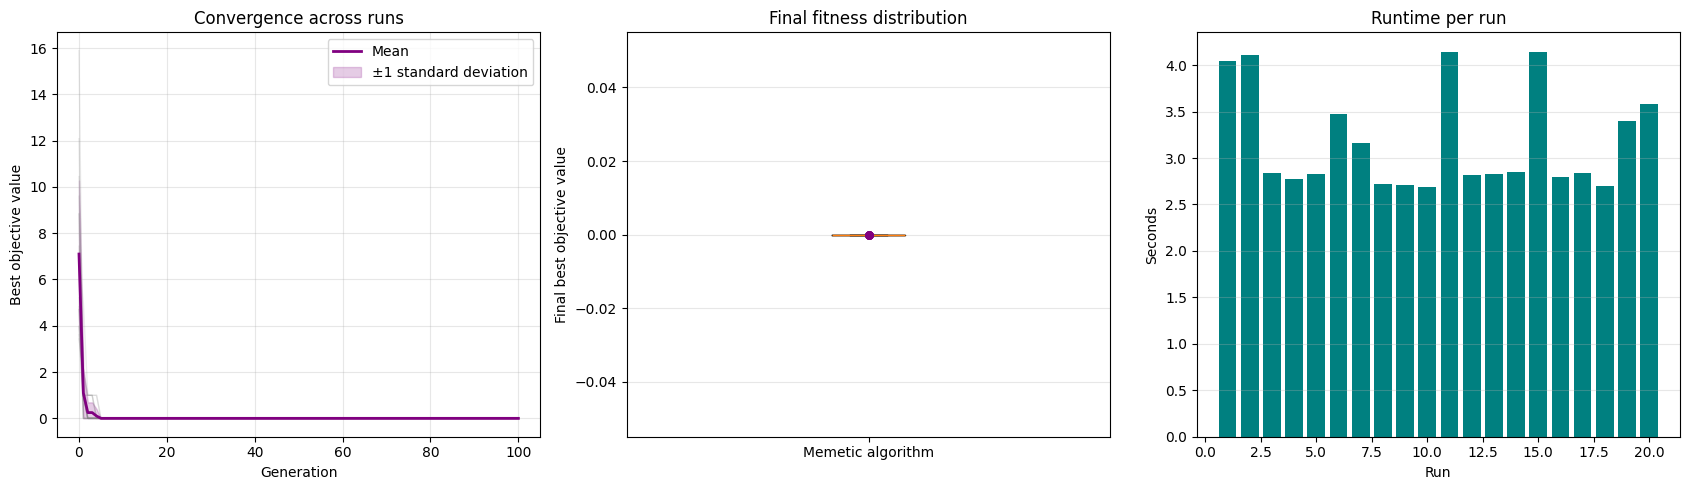

In [24]:
plot_statistical_results(all_results)